# Check Supervised Patch Strategy

This notebook validates the exact paired normalization and foreground patch filtering helpers used by `AO2DPairDataset`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

repo = Path.cwd()
if not (repo / 'src').exists():
    repo = Path('/root/dyx/AAAI')
sys.path.insert(0, str(repo))
sys.path.insert(0, str(repo / 'src'))

from ao2d.data.dataset import _foreground_fraction, _normalize_pair01, _random_foreground_crop_pair
from ao2d.data.io import load_image
from scripts.train_supervised import read_config, make_dataset

config_path = repo / 'configs/supervised_rcan2d_small.json'
data_root = Path('/mnt/share/dyx/Data/Data2d')
config = read_config(config_path)
train_set = make_dataset(config, 'train', data_root)

train_cfg = config['data']['train']
threshold = float(train_cfg.get('foreground_threshold', 0.03))
min_fraction = train_cfg.get('min_foreground_fraction')
print(f'num records: {len(train_set.records)}')
print(f'patch_size: {train_set.patch_size}')
print(f'foreground_threshold: {threshold}')
print(f'min_foreground_fraction: {min_fraction}')
print(f'max_patch_tries: {train_set.max_patch_tries}')

num records: 2000
patch_size: (256, 256)
foreground_threshold: 0.2
min_foreground_fraction: 0.05
max_patch_tries: 20


## Direct Helper Check

This cell calls the same helper functions from `src/ao2d/data/dataset.py` that the dataset uses internally.

In [2]:
record = train_set.records[0]
raw_x = load_image(record.aberrated)
raw_y = load_image(record.target)
norm_x, norm_y = _normalize_pair01(raw_x, raw_y, train_set.normalize_percentile)
crop_x, crop_y = _random_foreground_crop_pair(
    norm_x,
    norm_y,
    train_set.patch_size,
    train_set.min_foreground_fraction,
    train_set.foreground_threshold,
    train_set.max_patch_tries,
)

print(f'raw shapes: input={raw_x.shape}, target={raw_y.shape}')
print(f'normalized input range: ({norm_x.min():.4f}, {norm_x.max():.4f})')
print(f'normalized target range: ({norm_y.min():.4f}, {norm_y.max():.4f})')
print(f'crop shapes: input={crop_x.shape}, target={crop_y.shape}')
print(f'crop foreground fraction: {_foreground_fraction(crop_y, threshold):.4f}')

raw shapes: input=(512, 640), target=(512, 640)
normalized input range: (0.0000, 1.0000)
normalized target range: (0.0000, 1.0000)
crop shapes: input=(256, 256), target=(256, 256)
crop foreground fraction: 0.0761


## End-To-End Dataset Sampling

This cell samples through `train_set[i]`, which is the same code path used by the training `DataLoader`.

foreground fraction: min=0.0006, median=0.0994, max=0.3410
target mean:         min=0.0144, median=0.0746, max=0.1911
target max:          min=0.7460, median=1.0000, max=1.0000


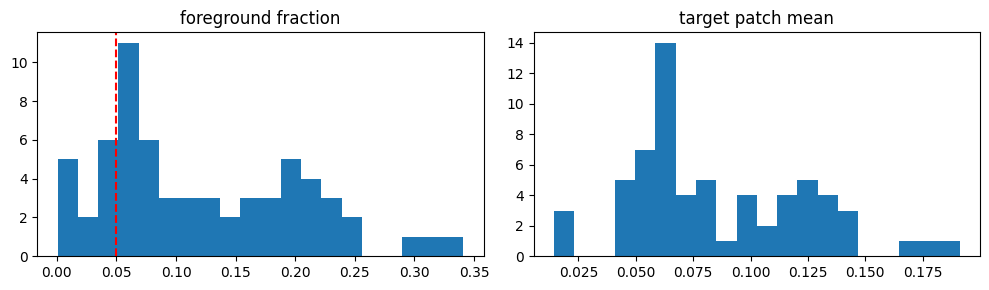

In [3]:
n = 64
fractions = []
means = []
maxes = []
for i in range(n):
    sample = train_set[i]
    y = sample['target'].squeeze(0).numpy()
    fractions.append(_foreground_fraction(y, threshold))
    means.append(float(y.mean()))
    maxes.append(float(y.max()))

print(f'foreground fraction: min={min(fractions):.4f}, median={np.median(fractions):.4f}, max={max(fractions):.4f}')
print(f'target mean:         min={min(means):.4f}, median={np.median(means):.4f}, max={max(means):.4f}')
print(f'target max:          min={min(maxes):.4f}, median={np.median(maxes):.4f}, max={max(maxes):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(fractions, bins=20)
ax[0].axvline(float(min_fraction or 0), color='r', linestyle='--')
ax[0].set_title('foreground fraction')
ax[1].hist(means, bins=20)
ax[1].set_title('target patch mean')
plt.tight_layout()

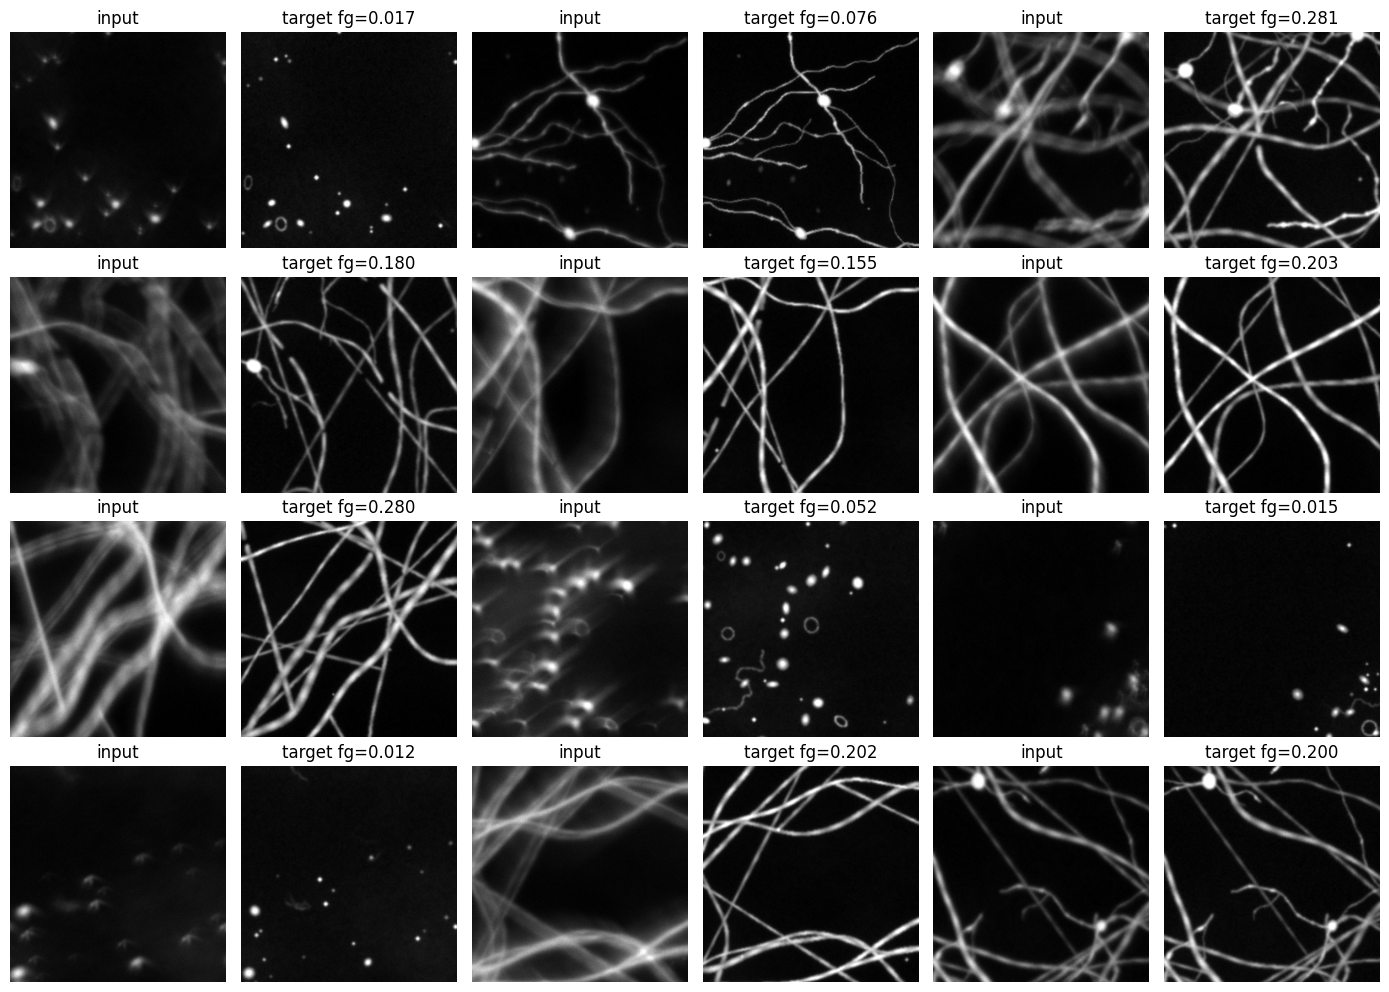

In [4]:
rows, cols = 4, 3
fig, axes = plt.subplots(rows, cols * 2, figsize=(14, 10))
for r in range(rows):
    for c in range(cols):
        sample = train_set[np.random.randint(0, len(train_set))]
        x = sample['input'].squeeze(0).numpy()
        y = sample['target'].squeeze(0).numpy()
        frac = _foreground_fraction(y, threshold)
        ax_x = axes[r, c * 2]
        ax_y = axes[r, c * 2 + 1]
        ax_x.imshow(x, cmap='gray', vmin=0, vmax=1)
        ax_x.set_title('input')
        ax_y.imshow(y, cmap='gray', vmin=0, vmax=1)
        ax_y.set_title(f'target fg={frac:.3f}')
        ax_x.axis('off')
        ax_y.axis('off')
plt.tight_layout()